In [16]:
# Step 1: Import libraries and connect to WRDS
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import getpass

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Connect to WRDS
user = input("Enter WRDS username: ")
password = getpass.getpass("Enter WRDS password: ")
conn = wrds.Connection(wrds_username=user, password=password)
print("WRDS connection established.")

Enter WRDS username:  yuhanshu
Enter WRDS password:  ········


Loading library list...
Done
WRDS connection established.


In [17]:
# Step 2: Define a function to download industry data with flexible parameters
def fetch_industry_data(conn, sich_from, sich_to, start_year):
    """
    Download financial data from Compustat Fundamentals Annual for a given SICH range.
    Parameters:
        conn: wrds connection object
        sich_from: start SICH code (e.g., '7370')
        sich_to: end SICH code (e.g., '7379')
        start_year: earliest fiscal year to include (e.g., 2018)
    Returns:
        pandas DataFrame with raw data
    """
    query = f"""
    SELECT gvkey, tic, fyear, datadate, sich,
           at, ceq, ni, sale, prcc_f, csho
    FROM comp.funda
    WHERE sich BETWEEN '{sich_from}' AND '{sich_to}'
      AND fyear >= {start_year}
      AND indfmt = 'INDL'
      AND datafmt = 'STD'
      AND consol = 'C'
      AND popsrc = 'D'
    """
    print("Downloading data from WRDS, please wait...")
    df = conn.raw_sql(query)
    print(f"Download complete. Total rows: {len(df)}")
    return df

In [18]:
# Step 3.1: Fetch technology sector data (SICH 7370-7379, from 2018)
df_raw = fetch_industry_data(conn, '7370', '7379', 2018)

# Quick overview
print("\nFirst 5 rows of raw data:")
print(df_raw.head())
print("\nColumn info:")
print(df_raw.info())

Download complete. Total rows: 5031

First 5 rows of raw data:
    gvkey   tic  fyear    datadate  sich       at      ceq      ni     sale  \
0  001084  WDDD   2018  2018-12-31  7370    3.846   -0.595   1.754      0.0   
1  001562  LGTY   2018  2019-04-30  7372   161.31  114.607   6.803  108.706   
2  001878  ADSK   2018  2019-01-31  7370   4729.2   -210.9   -80.8   2569.8   
3  001891   ADP   2018  2018-06-30  7374  37088.7   3459.6  1620.8  13325.8   
4  002504   UIS   2018  2018-12-31  7373   2457.6  -1343.5    75.5   2825.0   

   prcc_f    csho  
0    0.21  56.815  
1   12.95  31.213  
2   147.2   219.4  
3  134.14   438.8  
4   11.63    51.1  

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5031 entries, 0 to 5030
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   gvkey     5031 non-null   string 
 1   tic       5031 non-null   string 
 2   fyear     5031 non-null   Int64  
 3   datadate  5031 non-nu

In [19]:
# Step 3.2: Display all available tickers in a compact grid table
from IPython.display import display, HTML

all_tickers = sorted(df_raw['tic'].dropna().unique())
total = len(all_tickers)

# Aim for about 20 rows, calculate how many columns we need
target_rows = 20
num_cols = -(-total // target_rows)  # ceiling division

# Pad the list with empty strings so it fills the last row evenly
padded = all_tickers + [''] * (num_cols - (total % num_cols)) if total % num_cols else all_tickers.copy()

# Reshape into a list of rows (each row has num_cols items)
rows = [padded[i:i + num_cols] for i in range(0, len(padded), num_cols)]

# Build HTML table
html = '<table border="1" style="border-collapse:collapse; font-size:10px; text-align:center;">'
for row in rows:
    html += '<tr>' + ''.join(f'<td style="padding:2px 6px;">{t}</td>' for t in row) + '</tr>'
html += '</table>'

# Wrap in a scrollable container with fixed height
html = f"""
<div style='max-height:500px; overflow-y:scroll; border:1px solid #ccc; padding:5px;'>
    {html}
</div>
"""

display(HTML(html))
print(f"Total tickers: {total}  |  Table layout: ~{len(rows)} rows × {num_cols} columns")

8077B,ABILF,ABST,ABTC,ABTS,ACCS,ACIW,ACON,ADBE,ADCOF,ADEA,ADGO,ADP,ADSK,ADTH,AERA,AEYE,AGILQ,AGMH,AGYS,AHI,AI,AIB,AIFF,AIJTY,AIOT,AIP,AIRE,AISP,AIXI,AKAM,AKLI,ALAR,ALFIQ,ALIT,ALJJ,ALKT,ALLT,ALOY,ALRM,ALTR,AMBR,AMBR.2,AMJT,AMK,AMOD,AMPL,AMRH,AMST,AMWL,ANAV
ANGI,ANSS,ANY,API,APLD,APP,APPF,APPN,APPS,ARAT,ARBB,ARBK,AREN,ARQQ,ASAN,ASAPQ,ASUR,ATEA,ATEN,ATGL,ATHM,ATHR,ATTOF,ATTU,ATVI,AUGX,AUID,AUR,AUTO,AUUD,AVAI,AVCTQ,AVLR,AVPT,AVYAQ,AWRE,AXNVF,AYX,AZPN,BABA,BAH,BAND,BASE,BB,BBAI,BCDMF,BCOV,BDCC,BDGY,BETSF,BFH
BFRG,BHATF,BIDU,BILI,BILL,BITA,BKI,BKNG,BKSY,BL,BLCT,BLIN,BLIV,BLKB,BLND,BLZE,BMBL,BMNR,BMR,BMTX,BNAI,BNFT,BNZI,BOX,BR,BRAG,BRAI,BRQSF,BRRN.1,BRZE,BSMZF,BSY,BTBT,BTCS,BTCT,BTDR,BTGO,BTM,BTOG,BTRS,BTTC,BTTX,BTZI,BVSN,BZFD,CACI,CANG,CANPY,CARB.2,CARG,CARS
CBLK,CCC,CCIHY,CCLD,CCRC,CCRD,CCSI,CD,CD.1,CDK,CDLX,CDNS,CEENQ,CERN,CERT,CFLT,CGNT,CHGG,CHKP,CHNG,CHOW,CICN,CIFR,CIH,CINT,CISN,CISO,CLBT,CLDR,CLGX,CLIS,CLPS,CLRI,CLSK,CLVT,CMCM,CMRC,CNDT,CNFN,CNSWF,CNVY,CNXC,CORZ,COUP,CPAH,CPAY,CRCL,CRCM,CREX,CRGO,CRM
CRNC,CRSF,CRTD,CRVW,CRWD,CRWV,CSAI,CSGP,CSGS,CSLT,CSOD,CSPI,CSVI,CTEK,CTEV,CTG,CTKYY,CTLP,CTM,CTSH,CTW,CTXS,CURI,CVLT,CVOSF,CVT,CVTV,CWAN,CXAI,CXDO,CXM,CYBF,CYBR,CYN,CYOU,CYRNQ,CYXTQ,DAIC,DASH,DASTY,DATA,DAVA,DAY,DBX,DCBO,DCT,DDOG,DECN,DESP,DFIN,DFNS
DGNX,DGXX,DH,DHX,DJCO,DJT,DKI,DMRC,DOCN,DOCS,DOCU,DOMO,DOX,DOYU,DPSI,DSGX,DSNY,DSP,DSS,DT,DTCX,DTLIF,DTRK,DTSS,DTST,DUO,DV,DWAY,DWCH,DXC,DXF,EA,EAGRF,EB,EBIXQ,ECOM,EFOR,EGAN,EGHT,EGIOQ,EGOV,EIGI,ELLI,ELRE,EMBK,ENFN,EPAM,EPAY,EPOW,EPWKF,ESLT
ESMT,ESTC,ETSY,ETWO,EVBG,EVCM,EVER,EVH,EVOL,EVOP,EVTC,EXFY,EXLS,EXOD,FALC,FATN,FCCN,FDBL,FDC,FDS,FENG,FFIV,FICO,FIG,FINR,FINV,FIS,FISV,FIVN,FJTSY,FMHS,FNJN,FORA,FORG,FORTY,FOUR,FOXO,FRNKF,FROG,FRSH,FSCT,FSLY,FTCHQ,FTEO,FTFT,FTNT,FUBO,FUFU,FVRR,G,GAHC
GAIA,GAME,GAMG,GAN,GB,GDDY,GDEV,GDRX,GDS,GDYN,GEN,GENI,GET,GGRP,GIB,GIFT,GIGM,GITS,GLE,GLOB,GLOO,GLOW.,GLUU,GMHS,GOLQ,GOOGL,GPN,GRDI,GREE,GRND,GROM,GROO,GRPN,GRRR,GRUB.2,GRVY,GRWC,GSB,GSKY,GSUM,GTLB,GTM,GTYH,GWAV,GWRE,GXAI,HCAT,HCP,HCTI,HHER,HHR
HIVE,HKIT,HNGE,HOILF,HPAI,HPIL,HPTO,HQY,HSTM,HTCR,HTFL,HUBC,HUBS,HUT,HUYA,HWH,HWNI,HYREQ,IAC,IAS,IBEX,IBM,ICAD,ICCT,IDAI,IDN,IFBD,IGOT,IH,III,IIIV,IIJIY,IMCI,IMMR,INAPQ,INFA,INFO.1,INFY,INLX,INOD,INOV.1,INQR,INST,INST.1,INTA,INTU,INTZ,INUV,INVU,INXN,IOT
IPDN,IPM,IQ,IREN,IRNC,IRNTQ,IS,ISGN,ISPC,ITMSF,ITOC,IVDA,IWSY,IZEA,J,JAMF,JCS,JF,JFU,JG,JKHY,JOYY,JPOTF,JZ,KALO,KARO,KBNT,KBR,KC,KD,KDOZF,KEEL,KEYW,KLR,KLTR,KNBE,KNIT,KNRX,KONMY,KRKR,KTOS,KVYO,KXSCF,LAW,LAWR,LBRDK,LCFY,LCHD,LDOS,LEAF,LFLH
LGMK,LGTY,LIF,LINX,LIVC,LKCOF,LMFA,LMGIF,LN,LOGM,LOVLQ,LPSN,LSAK,LSPD,LTCH,LTRPA,LVBX,LVNSF,LVO,LVOX,LZGI,MAGTF,MAMS,MANH,MANT,MAPS,MARA,MARK,MASK,MAX,MAXD,MBLY,MCFE,MCOM,MDB,MDLA,MDRX,MDSO,MEET,MELI,META,MFGP,MFON,MGIC,MGNI,MGRT,MGTI,MI,MIGI,MIME,MITK


Total tickers: 1012  |  Table layout: ~20 rows × 51 columns


In [20]:
# Step 4: Clean data and compute financial ratios
df = df_raw.copy()

# Remove rows with non-positive equity 
df = df[df['ceq'] > 0]

# Compute ratios
df['roe']            = df['ni'] / df['ceq']                  # Return on Equity
df['profit_margin']  = df['ni'] / df['sale']                 # Net Profit Margin
df['asset_turnover'] = df['sale'] / df['at']                 # Asset Turnover
df['leverage']       = (df['at'] - df['ceq']) / df['at']    # Debt-to-Assets (Leverage)
df['pb']             = (df['prcc_f'] * df['csho']) / df['ceq'] # Price-to-Book

# Remove extreme outliers
df = df[(df['roe'] > -10) & (df['roe'] < 10)]

print("Ratios computed. Sample data:")
print(df[['tic', 'fyear', 'roe', 'profit_margin', 'asset_turnover', 'leverage', 'pb']].head())

Ratios computed. Sample data:
    tic  fyear       roe  profit_margin  asset_turnover  leverage        pb
1  LGTY   2018  0.059359       0.062582        0.673895  0.289523  3.526908
3   ADP   2018  0.468493       0.121629        0.359295  0.906721  17.01371
5  RAMP   2018   0.77286       3.601103        0.193915  0.096461  2.816922
6  CSPI   2018  0.427194       0.198036         1.31915  0.388476  1.559169
8  CACI   2018  0.142955       0.067408        1.107494  0.477778  1.976435


In [21]:
# Step 5: Calculate industry median for each year (benchmark)
industry_median = df.groupby('fyear').agg(
    median_roe            = ('roe', 'median'),
    median_profit_margin  = ('profit_margin', 'median'),
    median_asset_turnover = ('asset_turnover', 'median'),
    median_leverage       = ('leverage', 'median'),
    median_pb             = ('pb', 'median')
).reset_index()

print("Industry median benchmarks by year:")
print(industry_median)

Industry median benchmarks by year:
   fyear  median_roe  median_profit_margin  median_asset_turnover  \
0   2018    0.017082              0.011908               0.620094   
1   2019   -0.021359             -0.013878               0.552386   
2   2020   -0.033604             -0.036309               0.489346   
3   2021   -0.058125             -0.072431               0.439937   
4   2022   -0.118392             -0.104258               0.502012   
5   2023   -0.067255             -0.068714               0.541174   
6   2024   -0.012044             -0.013907               0.540743   
7   2025    0.027484              0.017612               0.571851   

   median_leverage  median_pb  
0         0.491817   4.088131  
1         0.512834   4.288839  
2         0.499521   5.719706  
3         0.447692    4.44162  
4         0.459096   2.413475  
5         0.461679   2.813681  
6         0.458527   3.142409  
7         0.440917   3.523685  


In [22]:
# Step 6.1: Filter data for selected companies
# USER INPUT: change tickers below as needed
selected_tickers = ['MSFT', 'GOOGL']   # AAPL removed because it was not in this SIC range
# =========================================================

selected_df = df[df['tic'].isin(selected_tickers)]
found = list(selected_df['tic'].unique())
print(f"Companies found in data: {found}")
missing = set(selected_tickers) - set(found)
if missing:
    print(f"Warning: the following tickers were not found: {missing}")

Companies found in data: ['MSFT', 'GOOGL']


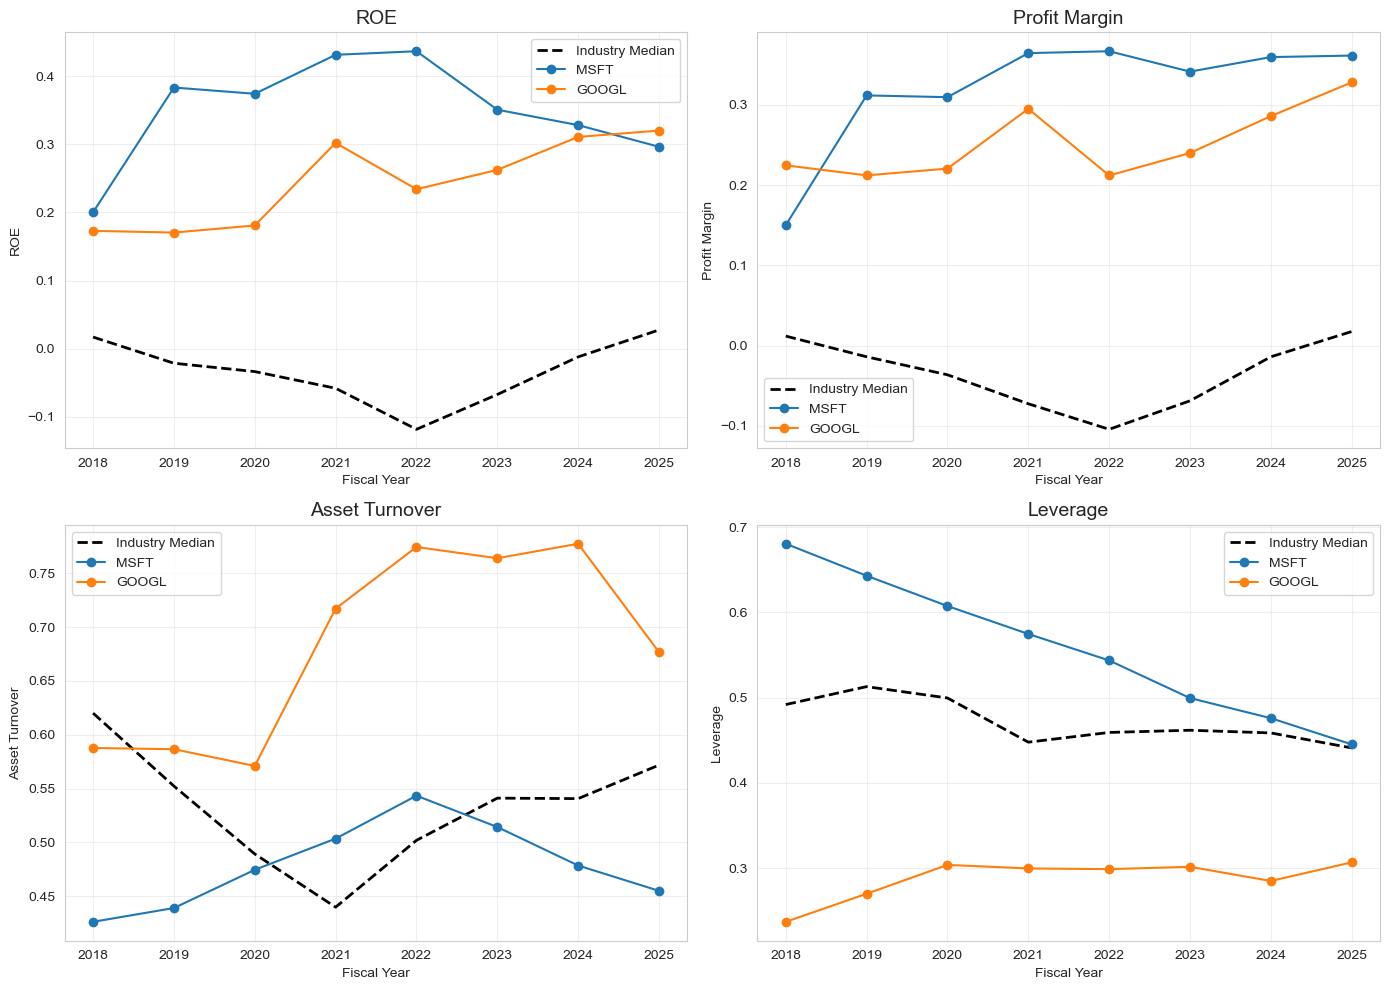

Line charts commentary (latest fiscal year):

ROE (Industry Median = 0.027):
  MSFT: 0.296 -> above industry median.
  GOOGL: 0.320 -> above industry median.

Profit Margin (Industry Median = 0.018):
  MSFT: 0.361 -> above industry median.
  GOOGL: 0.328 -> above industry median.

Asset Turnover (Industry Median = 0.572):
  MSFT: 0.455 -> below industry median.
  GOOGL: 0.677 -> above industry median.

Leverage (Industry Median = 0.441):
  MSFT: 0.445 -> above industry median.
  GOOGL: 0.307 -> below industry median.


In [23]:
# Step 6.2: Time-series comparison of four financial ratios
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
params = ['roe', 'profit_margin', 'asset_turnover', 'leverage']
titles = ['ROE', 'Profit Margin', 'Asset Turnover', 'Leverage']

for ax, param, title in zip(axes.flatten(), params, titles):
    ax.plot(industry_median['fyear'], industry_median[f'median_{param}'],
            color='black', linewidth=2, linestyle='--', label='Industry Median')
    for ticker in found:
        comp_data = selected_df[selected_df['tic'] == ticker]
        ax.plot(comp_data['fyear'], comp_data[param], marker='o', label=ticker)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Fiscal Year')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Generated explanation
latest_year = df['fyear'].max()
latest_ind = industry_median[industry_median['fyear'] == latest_year].iloc[0]
print("Line charts commentary (latest fiscal year):")
for param, label in zip(params, titles):
    ind_val = latest_ind[f'median_{param}']
    print(f"\n{label} (Industry Median = {ind_val:.3f}):")
    for ticker in found:
        comp = selected_df[(selected_df['tic'] == ticker) & (selected_df['fyear'] == latest_year)]
        if comp.empty:
            continue
        comp_val = comp[param].values[0]
        comparison = "above" if comp_val > ind_val else "below"
        print(f"  {ticker}: {comp_val:.3f} -> {comparison} industry median.")

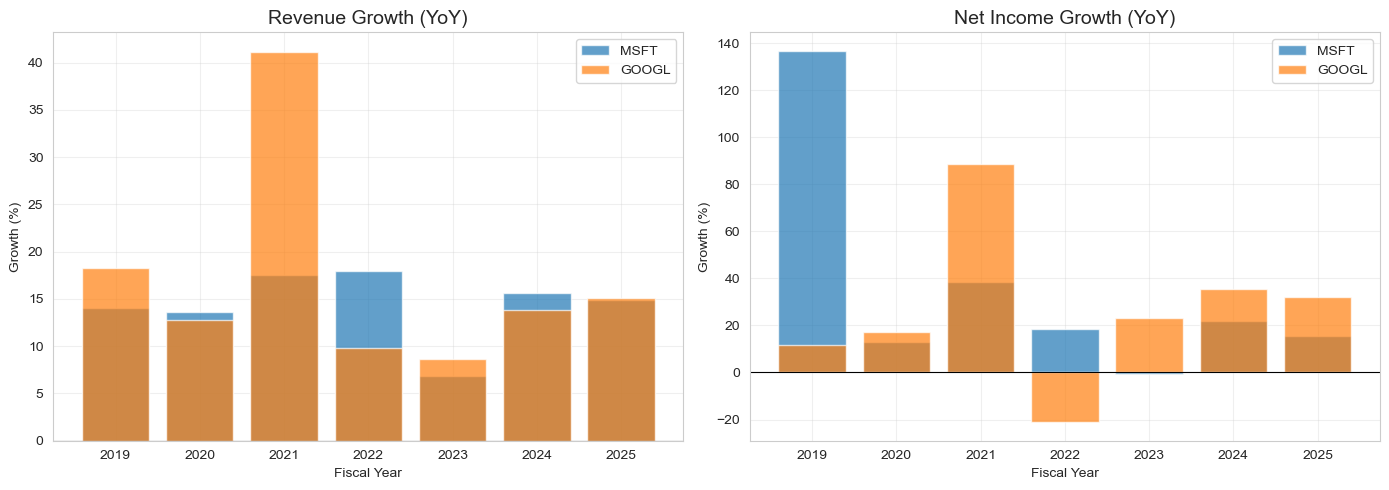


Growth chart commentary (most recent year-on-year):
  MSFT: Revenue grew by 14.9%, Net Income grew by 15.5%.
  GOOGL: Revenue grew by 15.1%, Net Income grew by 32.0%.


In [24]:
# Step 6.3: Revenue and Net Income Growth (Year-over-Year)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes, ['sale', 'ni'], ['Revenue Growth (YoY)', 'Net Income Growth (YoY)']):
    for ticker in found:
        comp_data = selected_df[selected_df['tic'] == ticker].sort_values('fyear')
        growth = comp_data[col].pct_change() * 100
        ax.bar(comp_data['fyear'].values[1:], growth.values[1:], alpha=0.7, label=ticker)
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Fiscal Year')
    ax.set_ylabel('Growth (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Generated explanation
latest_year = df['fyear'].max()
print("\nGrowth chart commentary (most recent year-on-year):")
for ticker in found:
    comp_data = selected_df[selected_df['tic'] == ticker].sort_values('fyear')
    if len(comp_data) < 2:
        print(f"  {ticker}: Not enough data for growth calculation.")
        continue
    rev_growth = (comp_data['sale'].iloc[-1] / comp_data['sale'].iloc[-2] - 1) * 100
    ni_growth = (comp_data['ni'].iloc[-1] / comp_data['ni'].iloc[-2] - 1) * 100
    rev_dir = "grew" if rev_growth > 0 else "declined"
    ni_dir = "grew" if ni_growth > 0 else "declined"
    print(f"  {ticker}: Revenue {rev_dir} by {rev_growth:.1f}%, Net Income {ni_dir} by {ni_growth:.1f}%.")

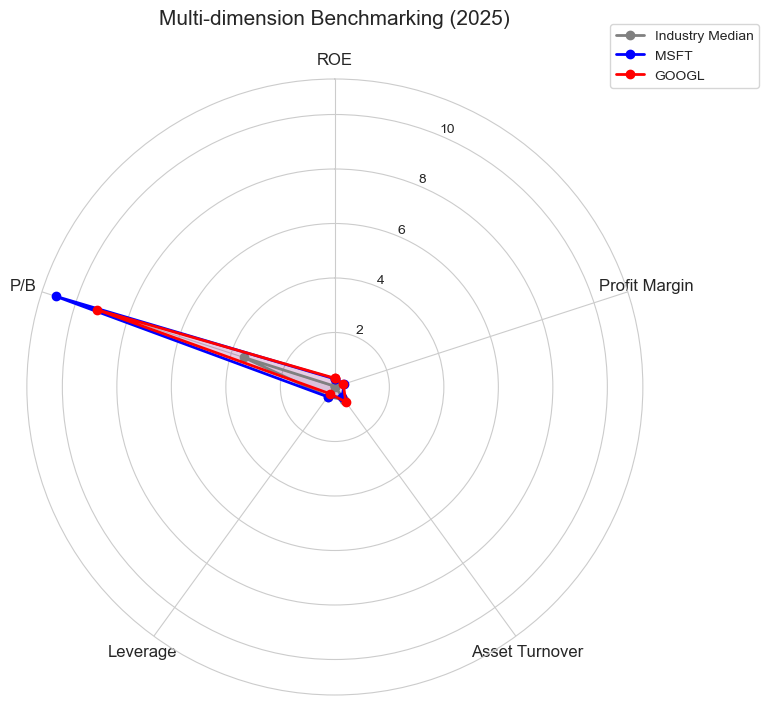


Radar chart commentary:
All axes are benchmarked against the industry median (grey area).

MSFT:
  ROE: 0.296 (industry median 0.027) -> higher than median
  Profit Margin: 0.361 (industry median 0.018) -> higher than median
  Asset Turnover: 0.455 (industry median 0.572) -> lower than median
  Leverage: 0.445 (industry median 0.441) -> higher than median
  P/B: 10.766 (industry median 3.524) -> higher than median

GOOGL:
  ROE: 0.320 (industry median 0.027) -> higher than median
  Profit Margin: 0.328 (industry median 0.018) -> higher than median
  Asset Turnover: 0.677 (industry median 0.572) -> higher than median
  Leverage: 0.307 (industry median 0.441) -> lower than median
  P/B: 9.168 (industry median 3.524) -> higher than median


In [25]:
# Step 6.4 Radar chart: multi-dimension snapshot for the latest year
latest_year = df['fyear'].max()
latest_ind = industry_median[industry_median['fyear'] == latest_year].iloc[0]
latest_sel = selected_df[selected_df['fyear'] == latest_year]

categories = ['ROE', 'Profit Margin', 'Asset Turnover', 'Leverage', 'P/B']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Industry median
values_ind = [latest_ind['median_roe'], latest_ind['median_profit_margin'],
              latest_ind['median_asset_turnover'], latest_ind['median_leverage'],
              latest_ind['median_pb']]
values_ind += values_ind[:1]
ax.plot(angles, values_ind, 'o-', linewidth=2, label='Industry Median', color='grey')
ax.fill(angles, values_ind, alpha=0.1, color='grey')

colors = ['b', 'r', 'g', 'orange', 'purple', 'brown']
for i, ticker in enumerate(found):
    comp = latest_sel[latest_sel['tic'] == ticker]
    if comp.empty:
        continue
    values_comp = [comp['roe'].values[0], comp['profit_margin'].values[0],
                   comp['asset_turnover'].values[0], comp['leverage'].values[0],
                   comp['pb'].values[0]]
    values_comp += values_comp[:1]
    ax.plot(angles, values_comp, 'o-', linewidth=2, label=ticker, color=colors[i % len(colors)])
    ax.fill(angles, values_comp, alpha=0.1, color=colors[i % len(colors)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_title(f'Multi-dimension Benchmarking ({latest_year})', size=15, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()

# Generated explanation
print("\nRadar chart commentary:")
print(f"All axes are benchmarked against the industry median (grey area).")
for ticker in found:
    comp = latest_sel[latest_sel['tic'] == ticker]
    if comp.empty:
        continue
    print(f"\n{ticker}:")
    for cat in categories:
        cat_key = cat.lower().replace(" ", "_").replace("/","").replace("-","")
        if cat_key == 'p/b': cat_key = 'pb'
        ind_val = latest_ind[f'median_{cat_key}']
        comp_val = comp[cat_key].values[0] if cat_key != 'pb' else comp['pb'].values[0]
        direction = "higher" if comp_val > ind_val else "lower"
        print(f"  {cat}: {comp_val:.3f} (industry median {ind_val:.3f}) -> {direction} than median")

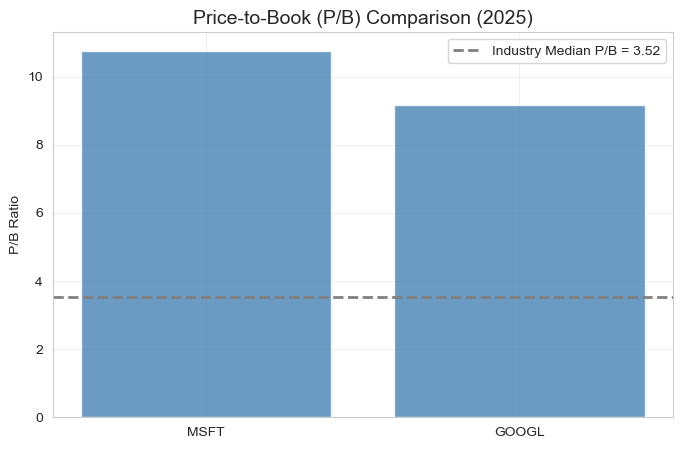


P/B chart commentary:
Industry median P/B: 3.52
  MSFT: P/B = 10.77 -> trading at a premium to the industry median.
  GOOGL: P/B = 9.17 -> trading at a premium to the industry median.


In [26]:
# Step 6.5: Price-to-Book (P/B) Snapshot for the Latest Year
latest_year = df['fyear'].max()
latest_ind_pb = industry_median[industry_median['fyear'] == latest_year]['median_pb'].values[0]

fig, ax = plt.subplots(figsize=(8, 5))
pb_dict = {}

for ticker in found:
    comp = selected_df[(selected_df['tic'] == ticker) & (selected_df['fyear'] == latest_year)]
    if comp.empty:
        continue
    pb_val = comp['pb'].values[0]
    pb_dict[ticker] = pb_val

ax.bar(pb_dict.keys(), pb_dict.values(), color='steelblue', alpha=0.8)
ax.axhline(y=latest_ind_pb, color='grey', linewidth=2, linestyle='--',
           label=f'Industry Median P/B = {latest_ind_pb:.2f}')
ax.set_title(f'Price-to-Book (P/B) Comparison ({latest_year})', fontsize=14)
ax.set_ylabel('P/B Ratio')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Generated explanation
print("\nP/B chart commentary:")
print(f"Industry median P/B: {latest_ind_pb:.2f}")
for ticker, pb_val in pb_dict.items():
    comp_str = "premium" if pb_val > latest_ind_pb else "discount"
    print(f"  {ticker}: P/B = {pb_val:.2f} -> trading at a {comp_str} to the industry median.")

In [27]:
# Step 7: Investment Summary

latest_year = df['fyear'].max()
latest_ind = industry_median[industry_median['fyear'] == latest_year].iloc[0]

print("=" * 60)
print(f"  INVESTMENT SUMMARY – Technology Sector ({latest_year})")
print("=" * 60)

for ticker in found:
    comp = selected_df[(selected_df['tic'] == ticker) & (selected_df['fyear'] == latest_year)]
    if comp.empty:
        continue

    roe = comp['roe'].values[0]
    margin = comp['profit_margin'].values[0]
    leverage = comp['leverage'].values[0]
    pb = comp['pb'].values[0]

    ind_roe = latest_ind['median_roe']
    ind_margin = latest_ind['median_profit_margin']
    ind_leverage = latest_ind['median_leverage']
    ind_pb = latest_ind['median_pb']

    comp_hist = selected_df[selected_df['tic'] == ticker].sort_values('fyear')
    if len(comp_hist) >= 2:
        rev_growth = (comp_hist['sale'].iloc[-1] / comp_hist['sale'].iloc[-2] - 1) * 100
        ni_growth = (comp_hist['ni'].iloc[-1] / comp_hist['ni'].iloc[-2] - 1) * 100
    else:
        rev_growth = ni_growth = None

    print(f"\n  >>> {ticker} <<<")
    print(f"  Profitability:   ROE {roe:.3f} vs median {ind_roe:.3f}  |  Margin {margin:.3f} vs median {ind_margin:.3f}")
    if rev_growth is not None:
        print(f"  Growth:          Revenue {rev_growth:+.1f}%  |  Net Income {ni_growth:+.1f}%")
    print(f"  Leverage:        {leverage:.3f} (median {ind_leverage:.3f})")
    print(f"  Valuation (P/B): {pb:.2f} (median {ind_pb:.2f})")

print("\n" + "-" * 60)
print("Disclaimer: This analysis uses historical data and sector medians.")
print("It is not investment advice. Past performance ≠ future results.")
print("-" * 60)

  INVESTMENT SUMMARY – Technology Sector (2025)

  >>> MSFT <<<
  Profitability:   ROE 0.296 vs median 0.027  |  Margin 0.361 vs median 0.018
  Growth:          Revenue +14.9%  |  Net Income +15.5%
  Leverage:        0.445 (median 0.441)
  Valuation (P/B): 10.77 (median 3.52)

  >>> GOOGL <<<
  Profitability:   ROE 0.320 vs median 0.027  |  Margin 0.328 vs median 0.018
  Growth:          Revenue +15.1%  |  Net Income +32.0%
  Leverage:        0.307 (median 0.441)
  Valuation (P/B): 9.17 (median 3.52)

------------------------------------------------------------
Disclaimer: This analysis uses historical data and sector medians.
It is not investment advice. Past performance ≠ future results.
------------------------------------------------------------


In [28]:
# Step 8: Close WRDS connection
conn.close()
print("WRDS connection closed.")

WRDS connection closed.
